In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

plt.style.use("ggplot")

In [4]:
df = pd.read_csv("../data/heart_failure_clinical_records_dataset.csv")

df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [5]:
X = df.drop("DEATH_EVENT", axis=1)
y = df["DEATH_EVENT"]

print(X.shape)
print(y.shape)

(299, 12)
(299,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [7]:
numerical_cols = [
    'age',
    'creatinine_phosphokinase',
    'ejection_fraction',
    'platelets',
    'serum_creatinine',
    'serum_sodium',
    'time'
]

In [8]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(
    X_train[numerical_cols]
)

X_test_scaled[numerical_cols] = scaler.transform(
    X_test[numerical_cols]
)

In [9]:
lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [10]:
y_pred = lr.predict(X_test_scaled)
y_prob = lr.predict_proba(X_test_scaled)[:,1]

In [11]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8167


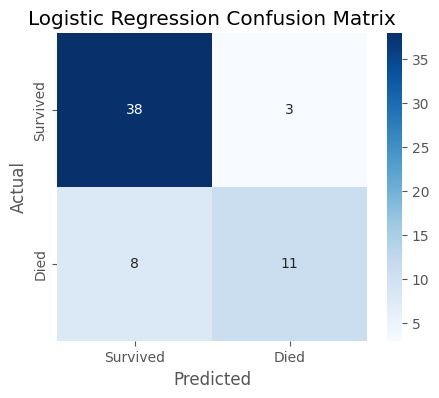

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Survived","Died"],
    yticklabels=["Survived","Died"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.93      0.87        41
           1       0.79      0.58      0.67        19

    accuracy                           0.82        60
   macro avg       0.81      0.75      0.77        60
weighted avg       0.81      0.82      0.81        60



In [14]:
roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {roc_auc:.4f}")


ROC-AUC Score: 0.8614


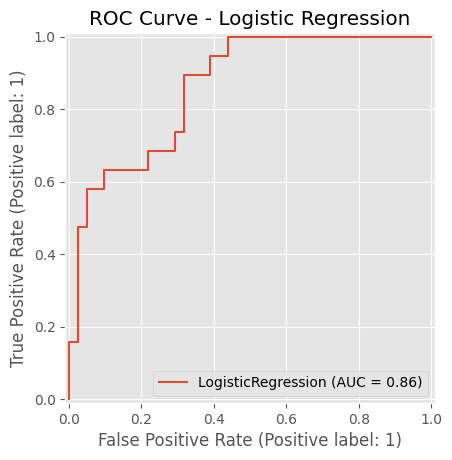

In [15]:
RocCurveDisplay.from_estimator(
    lr,
    X_test_scaled,
    y_test
)

plt.title("ROC Curve - Logistic Regression")

plt.show()

In [16]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_[0]
})

importance = importance.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

importance

,Feature,Coefficient
11,time,-1.578260
4,ejection_fraction,-0.903623
7,serum_creatinine,0.782835
3,diabetes,0.437645
0,age,0.411537
9,sex,-0.361736
2,creatinine_phosphokinase,0.269899
10,smoking,0.182248
1,anaemia,0.162105
8,serum_sodium,-0.137874


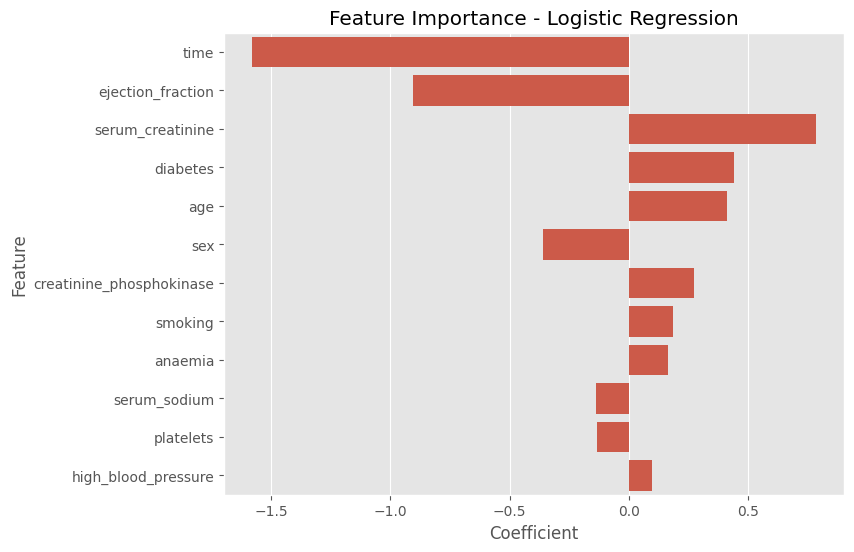

In [17]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance,
    x="Coefficient",
    y="Feature"
)

plt.title("Feature Importance - Logistic Regression")

plt.show()

In [18]:
results = pd.DataFrame(columns=[
    "Model",
    "Accuracy",
    "ROC-AUC"
])

results.loc[len(results)] = [
    "Logistic Regression",
    accuracy,
    roc_auc
]

results

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.816667,0.861361


In [19]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [20]:
dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=4
)

In [21]:
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [22]:
dt_pred = dt.predict(X_test)
dt_prob = dt.predict_proba(X_test)[:, 1]

In [23]:
dt_accuracy = accuracy_score(y_test, dt_pred)

print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")

Decision Tree Accuracy: 0.7500


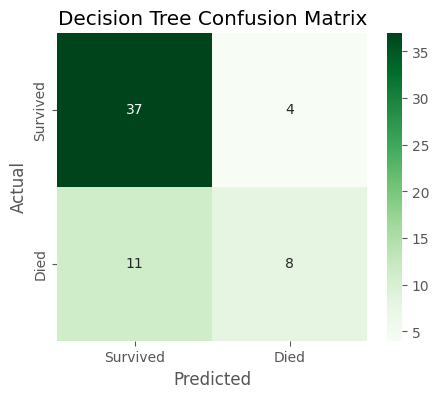

In [24]:
dt_cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    dt_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Survived", "Died"],
    yticklabels=["Survived", "Died"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

In [25]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.77      0.90      0.83        41
           1       0.67      0.42      0.52        19

    accuracy                           0.75        60
   macro avg       0.72      0.66      0.67        60
weighted avg       0.74      0.75      0.73        60



In [26]:
dt_auc = roc_auc_score(y_test, dt_prob)

print(f"Decision Tree ROC-AUC: {dt_auc:.4f}")

Decision Tree ROC-AUC: 0.6624


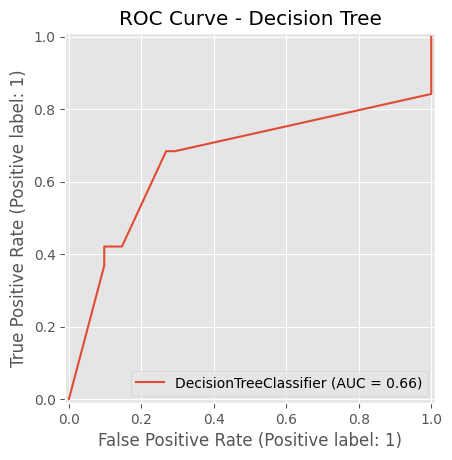

In [27]:
RocCurveDisplay.from_estimator(
    dt,
    X_test,
    y_test
)

plt.title("ROC Curve - Decision Tree")

plt.show()

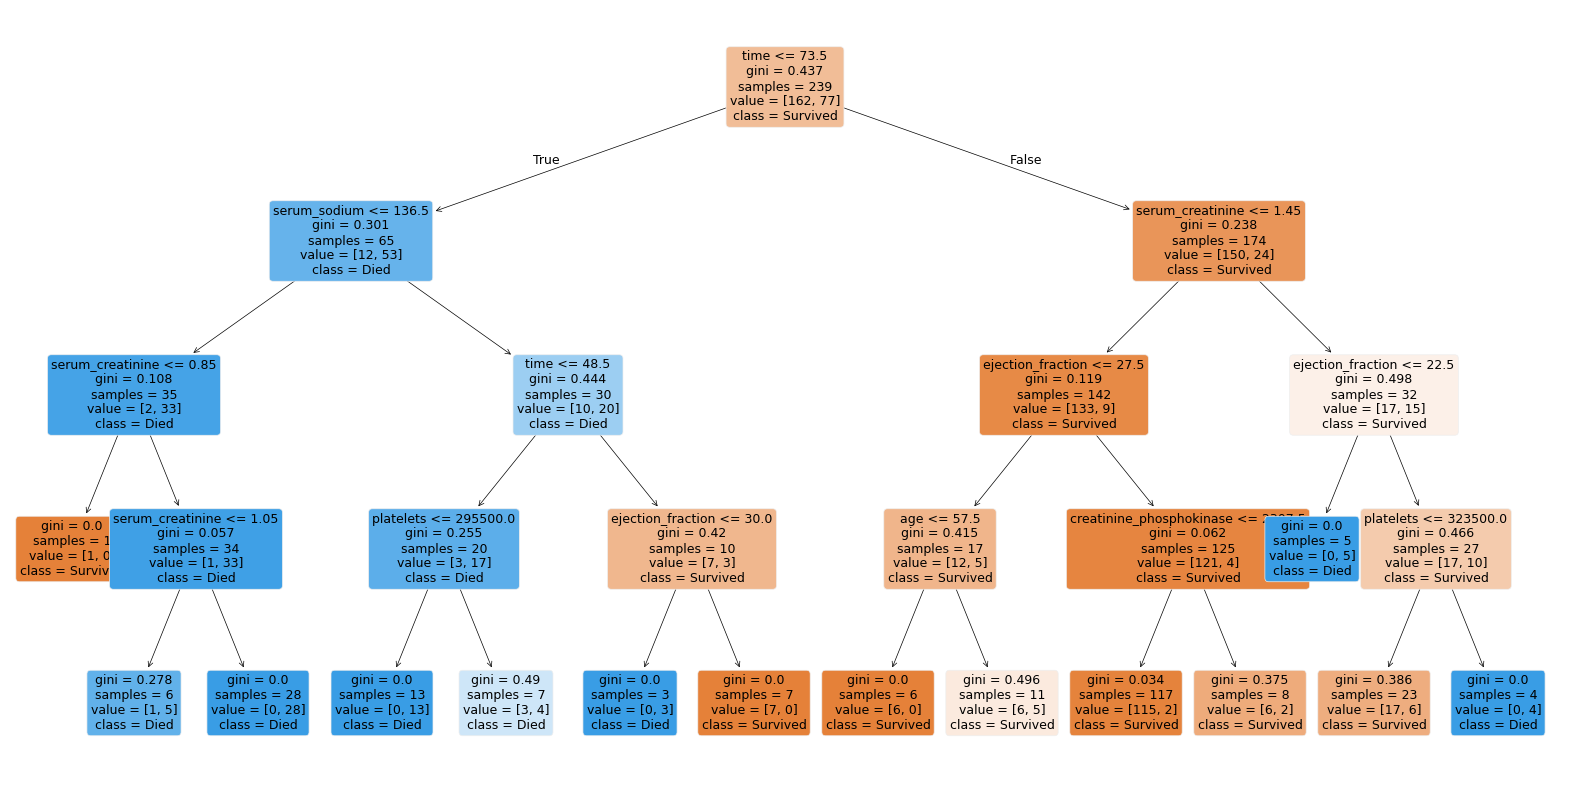

In [28]:
plt.figure(figsize=(20,10))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["Survived", "Died"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.show()

In [29]:
dt_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt.feature_importances_
})

dt_importance = dt_importance.sort_values(
    by="Importance",
    ascending=False
)

dt_importance

,Feature,Importance
11,time,0.608321
7,serum_creatinine,0.136959
4,ejection_fraction,0.123039
6,platelets,0.069130
8,serum_sodium,0.031582
0,age,0.020559
2,creatinine_phosphokinase,0.010411
1,anaemia,0.000000
3,diabetes,0.000000
5,high_blood_pressure,0.000000


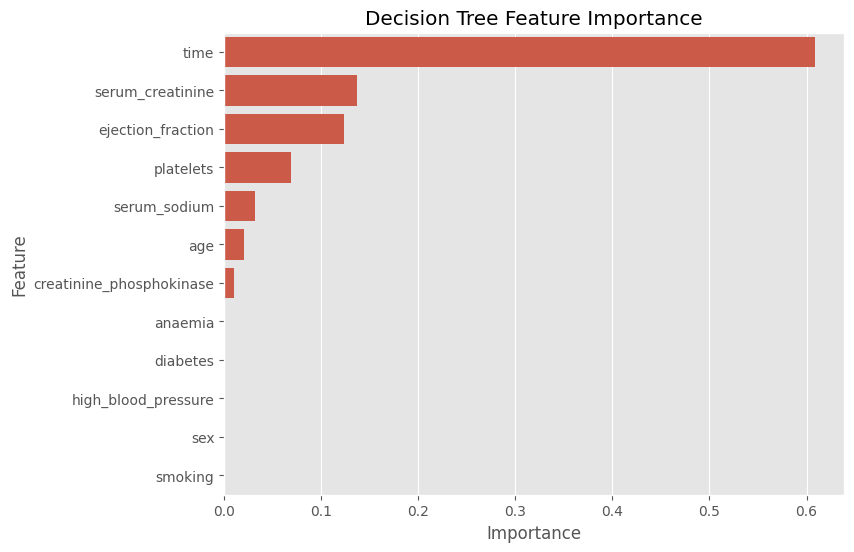

In [30]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=dt_importance,
    x="Importance",
    y="Feature"
)

plt.title("Decision Tree Feature Importance")

plt.show()

In [31]:
results.loc[len(results)] = [
    "Decision Tree",
    dt_accuracy,
    dt_auc
]

results

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.816667,0.861361
1,Decision Tree,0.750000,0.662388


In [32]:
from sklearn.ensemble import RandomForestClassifier

In [33]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=5
)

In [34]:
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

In [36]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

Random Forest Accuracy: 0.8500


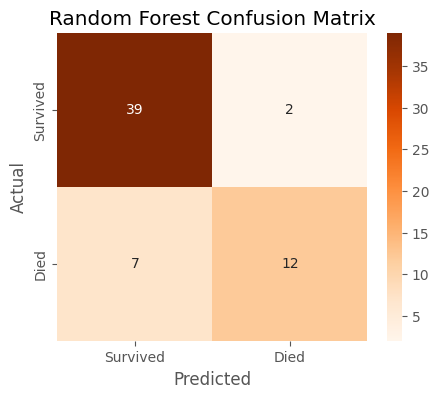

In [37]:
rf_cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Survived", "Died"],
    yticklabels=["Survived", "Died"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [38]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.85      0.95      0.90        41
           1       0.86      0.63      0.73        19

    accuracy                           0.85        60
   macro avg       0.85      0.79      0.81        60
weighted avg       0.85      0.85      0.84        60



In [39]:
rf_auc = roc_auc_score(y_test, rf_prob)

print(f"Random Forest ROC-AUC: {rf_auc:.4f}")

Random Forest ROC-AUC: 0.8999


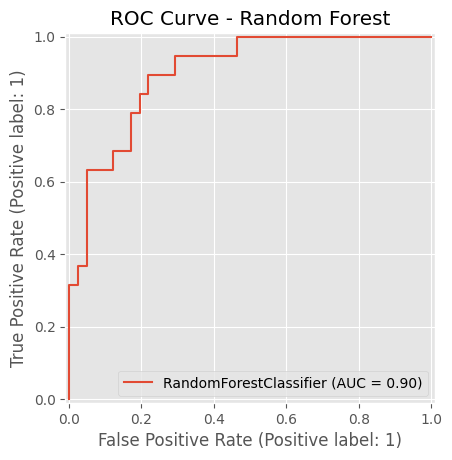

In [40]:
RocCurveDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.title("ROC Curve - Random Forest")

plt.show()

In [41]:
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

rf_importance

,Feature,Importance
11,time,0.409970
7,serum_creatinine,0.163743
4,ejection_fraction,0.141144
0,age,0.067824
2,creatinine_phosphokinase,0.063331
6,platelets,0.056355
8,serum_sodium,0.052520
5,high_blood_pressure,0.009565
3,diabetes,0.009431
10,smoking,0.009294


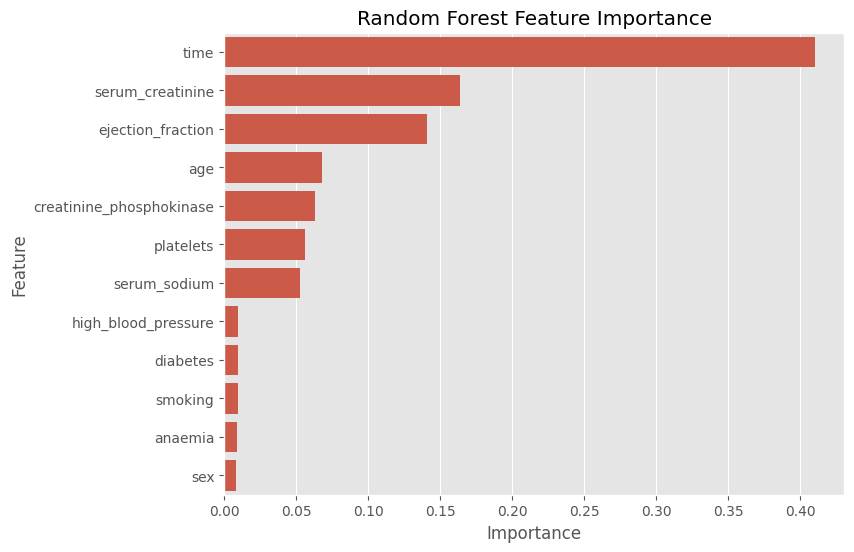

In [42]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=rf_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")

plt.show()

In [43]:
results.loc[len(results)] = [
    "Random Forest",
    rf_accuracy,
    rf_auc
]

results

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.816667,0.861361
1,Decision Tree,0.750000,0.662388
2,Random Forest,0.850000,0.899872


In [44]:
from sklearn.svm import SVC

In [45]:
svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42
)

In [46]:
svm.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [47]:
svm_pred = svm.predict(X_test_scaled)
svm_prob = svm.predict_proba(X_test_scaled)[:, 1]

In [48]:
svm_accuracy = accuracy_score(y_test, svm_pred)

print(f"SVM Accuracy: {svm_accuracy:.4f}")

SVM Accuracy: 0.7667


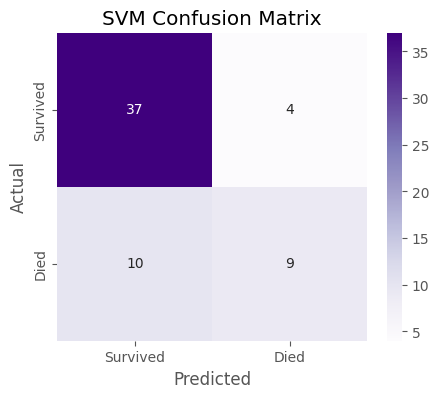

In [49]:
svm_cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    svm_cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Survived", "Died"],
    yticklabels=["Survived", "Died"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")

plt.show()

In [50]:
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

           0       0.79      0.90      0.84        41
           1       0.69      0.47      0.56        19

    accuracy                           0.77        60
   macro avg       0.74      0.69      0.70        60
weighted avg       0.76      0.77      0.75        60



In [51]:
svm_auc = roc_auc_score(y_test, svm_prob)

print(f"SVM ROC-AUC: {svm_auc:.4f}")

SVM ROC-AUC: 0.8703


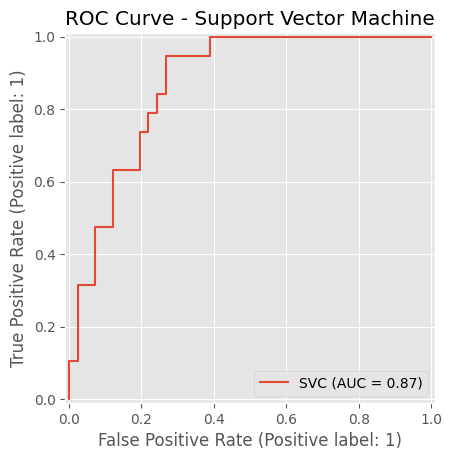

In [52]:
RocCurveDisplay.from_estimator(
    svm,
    X_test_scaled,
    y_test
)

plt.title("ROC Curve - Support Vector Machine")

plt.show()

In [53]:
results.loc[len(results)] = [
    "Support Vector Machine",
    svm_accuracy,
    svm_auc
]

results

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.816667,0.861361
1,Decision Tree,0.750000,0.662388
2,Random Forest,0.850000,0.899872
3,Support Vector Machine,0.766667,0.870347


In [54]:
from sklearn.ensemble import GradientBoostingClassifier

In [55]:
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [56]:
gb.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [57]:
gb_pred = gb.predict(X_test)
gb_prob = gb.predict_proba(X_test)[:, 1]

In [58]:
gb_accuracy = accuracy_score(y_test, gb_pred)

print(f"Gradient Boosting Accuracy: {gb_accuracy:.4f}")

Gradient Boosting Accuracy: 0.8333


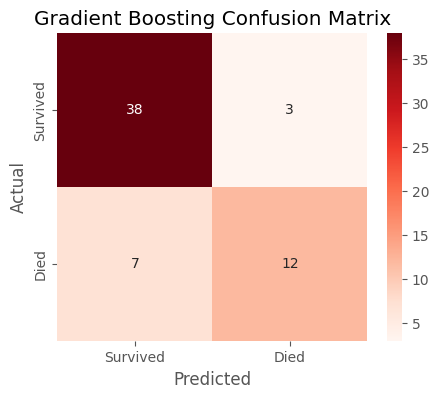

In [59]:
gb_cm = confusion_matrix(y_test, gb_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    gb_cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=["Survived", "Died"],
    yticklabels=["Survived", "Died"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Gradient Boosting Confusion Matrix")

plt.show()

In [60]:
print(classification_report(y_test, gb_pred))

              precision    recall  f1-score   support

           0       0.84      0.93      0.88        41
           1       0.80      0.63      0.71        19

    accuracy                           0.83        60
   macro avg       0.82      0.78      0.79        60
weighted avg       0.83      0.83      0.83        60



In [61]:
gb_auc = roc_auc_score(y_test, gb_prob)

print(f"Gradient Boosting ROC-AUC: {gb_auc:.4f}")

Gradient Boosting ROC-AUC: 0.8447


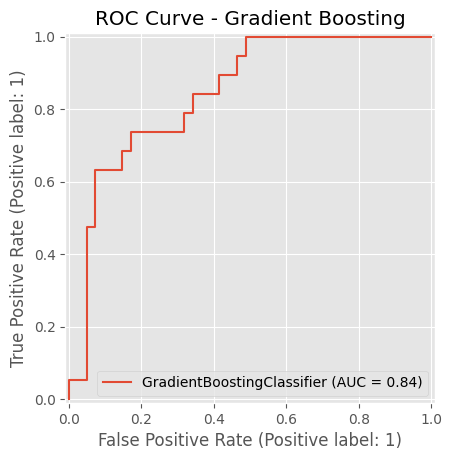

In [62]:
RocCurveDisplay.from_estimator(
    gb,
    X_test,
    y_test
)

plt.title("ROC Curve - Gradient Boosting")

plt.show()

In [64]:
gb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gb.feature_importances_
})

gb_importance = gb_importance.sort_values(
    by="Importance",
    ascending=False
)

gb_importance

,Feature,Importance
11,time,0.587590
7,serum_creatinine,0.122385
4,ejection_fraction,0.098449
6,platelets,0.068201
2,creatinine_phosphokinase,0.055924
8,serum_sodium,0.031526
0,age,0.024156
10,smoking,0.003155
9,sex,0.002998
3,diabetes,0.002411


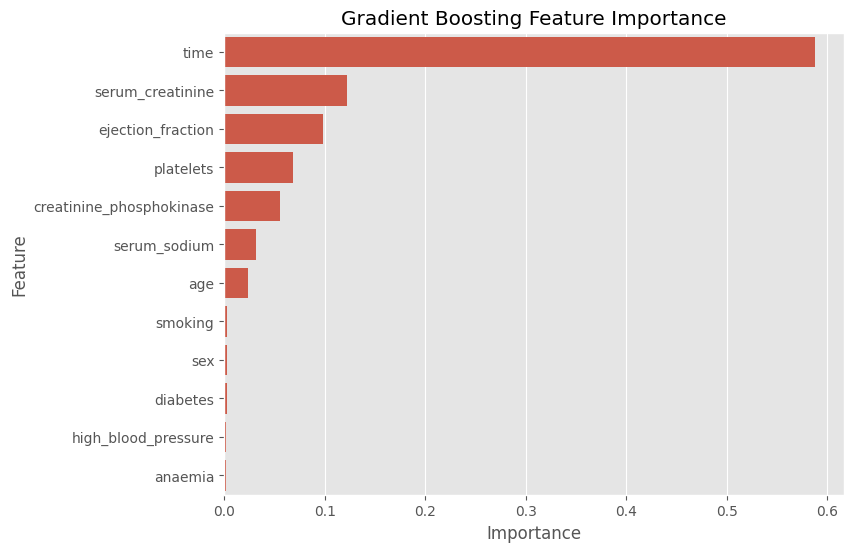

In [65]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=gb_importance,
    x="Importance",
    y="Feature"
)

plt.title("Gradient Boosting Feature Importance")

plt.show()

In [66]:
results.loc[len(results)] = [
    "Gradient Boosting",
    gb_accuracy,
    gb_auc
]

results

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.816667,0.861361
1,Decision Tree,0.750000,0.662388
2,Random Forest,0.850000,0.899872
3,Support Vector Machine,0.766667,0.870347
4,Gradient Boosting,0.833333,0.844673


# Hyperparameter Tuning

Hyperparameter tuning is performed to identify the optimal configuration of the Random Forest classifier.

GridSearchCV is used with 5-fold cross-validation to evaluate multiple parameter combinations and select the model with the best cross-validation accuracy.

In [67]:
from sklearn.model_selection import GridSearchCV

In [68]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [69]:
rf = RandomForestClassifier(random_state=42)

In [70]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=2
)

In [71]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [3, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


In [72]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}


In [73]:
print("Best Cross Validation ROC-AUC:")
print(grid_search.best_score_)

Best Cross Validation ROC-AUC:
0.9274423926767676


In [74]:
best_rf = grid_search.best_estimator_

In [75]:
best_pred = best_rf.predict(X_test)
best_prob = best_rf.predict_proba(X_test)[:,1]

In [76]:
best_accuracy = accuracy_score(y_test, best_pred)

print(f"Tuned Random Forest Accuracy: {best_accuracy:.4f}")

Tuned Random Forest Accuracy: 0.8333


In [77]:
print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

           0       0.84      0.93      0.88        41
           1       0.80      0.63      0.71        19

    accuracy                           0.83        60
   macro avg       0.82      0.78      0.79        60
weighted avg       0.83      0.83      0.83        60



In [78]:
best_auc = roc_auc_score(y_test, best_prob)

print(f"Tuned Random Forest ROC-AUC: {best_auc:.4f}")

Tuned Random Forest ROC-AUC: 0.9024


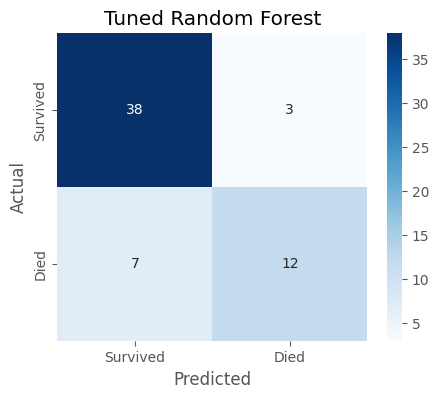

In [79]:
best_cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    best_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Survived", "Died"],
    yticklabels=["Survived", "Died"]
)

plt.title("Tuned Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [80]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
11,time,0.409785
7,serum_creatinine,0.155465
4,ejection_fraction,0.135945
0,age,0.070112
6,platelets,0.064462
2,creatinine_phosphokinase,0.063424
8,serum_sodium,0.049733
10,smoking,0.011560
1,anaemia,0.010613
3,diabetes,0.010532


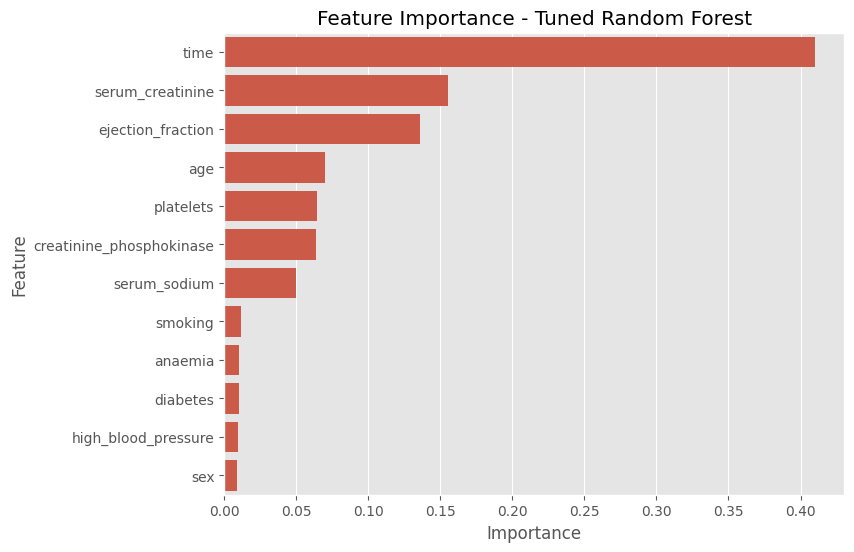

In [81]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Tuned Random Forest")

plt.show()

In [82]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Support Vector Machine",
        "Gradient Boosting",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy,
        rf_accuracy,
        svm_accuracy,
        gb_accuracy,
        best_accuracy
    ],
    "ROC-AUC": [
        roc_auc,
        dt_auc,
        rf_auc,
        svm_auc,
        gb_auc,
        best_auc
    ]
})

comparison.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,ROC-AUC
5,Tuned Random Forest,0.833333,0.902439
2,Random Forest,0.850000,0.899872
3,Support Vector Machine,0.766667,0.870347
0,Logistic Regression,0.816667,0.861361
4,Gradient Boosting,0.833333,0.844673
1,Decision Tree,0.750000,0.662388


In [83]:
import joblib
import os

In [84]:
joblib.dump(rf, "../models/heart_failure_rf_model.pkl")

['../models/heart_failure_rf_model.pkl']

In [85]:
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

In [86]:
os.listdir("../models")

['heart_failure_rf_model.pkl', 'scaler.pkl']

In [90]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=5
)

rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [91]:
joblib.dump(rf, "../models/heart_failure_rf_model.pkl")

['../models/heart_failure_rf_model.pkl']

In [92]:
loaded_model = joblib.load("../models/heart_failure_rf_model.pkl")

In [93]:
loaded_pred = loaded_model.predict(X_test)

print(
    accuracy_score(y_test, loaded_pred)
)

0.85


In [94]:
joblib.dump(
    best_rf,
    "../models/heart_failure_rf_model.pkl"
)

['../models/heart_failure_rf_model.pkl']

In [95]:
loaded_model = joblib.load(
    "../models/heart_failure_rf_model.pkl"
)

loaded_pred = loaded_model.predict(X_test)

print(
    accuracy_score(y_test, loaded_pred)
)

0.8333333333333334


# Final Conclusion

This project aimed to predict heart failure mortality using clinical records and multiple supervised machine learning algorithms.

A comprehensive exploratory data analysis (EDA) was first performed to understand the dataset, identify missing values, detect outliers, and analyze relationships between clinical features and the target variable.

Five classification algorithms were evaluated:

* Logistic Regression
* Decision Tree
* Random Forest
* Support Vector Machine (SVM)
* Gradient Boosting

The Random Forest classifier achieved the best overall performance with an accuracy of **85.00%** and a ROC-AUC score of **0.8999**. Hyperparameter tuning using GridSearchCV further improved the cross-validation ROC-AUC to **0.9274**, although the improvement on the independent test set was marginal.

Among all evaluated features, **time**, **ejection fraction**, **serum creatinine**, and **age** were identified as the most influential predictors of heart failure mortality. These findings are consistent with established clinical knowledge regarding heart failure prognosis.

Overall, the Random Forest classifier provided the best balance between predictive accuracy and discrimination capability, making it the preferred model for this dataset.

### Future Work

* Train on larger multi-center datasets.
* Address class imbalance using techniques such as SMOTE.
* Evaluate advanced ensemble methods such as XGBoost and LightGBM.
* Deploy the trained model as a web application using Streamlit or Flask.
* Incorporate explainable AI techniques such as SHAP or LIME for improved clinical interpretability.
